# 🔍 Exploratory Data Analysis — Healthcare Financial Dataset

**Author:** Ayushi Dhimmar  
**Dataset:** Healthcare Financial Performance (500 rows, 12 columns)  
**Goal:** Uncover patterns, trends, and insights from the healthcare financial data

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings = __import__('warnings'); warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.facecolor'] = '#0A1628'
plt.rcParams['axes.facecolor'] = '#0D2137'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
GREEN = '#00C853'
BLUE = '#1565C0'

# Load pre-cleaned and normalized data
df = pd.read_csv('../data/healthcare_normalized.csv')
df['Date'] = pd.to_datetime(df['Date'])
print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns ✅')

Dataset loaded: 500 rows, 16 columns ✅


## 2. Overview Statistics

In [2]:
print('=== Key Financial KPIs ===')
print(f"Total Revenue:   ₹ {df['Total_Revenue'].sum():,.0f}")
print(f"Total Expense:   ₹ {df['Expense'].sum():,.0f}")
print(f"Total Profit:    ₹ {df['Profit'].sum():,.0f}")
print(f"Avg Profit Margin: {df['Profit_Margin'].mean()*100:.2f}%")
print(f"Total Patients:  {df['Number_of_Patients'].sum():,}")

=== Key Financial KPIs ===
Total Revenue:   ₹ 1,886,235,034
Total Expense:   ₹ 1,314,299,830
Total Profit:    ₹ 571,935,204
Avg Profit Margin: 29.83%
Total Patients:  12,851


## 3. Revenue vs Expense by Region

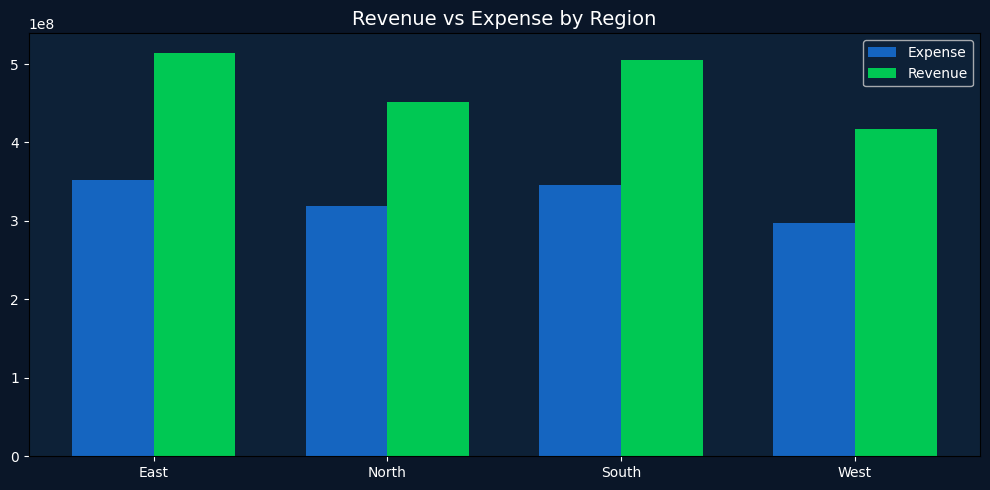


South region has the highest revenue: East


In [3]:
region_df = df.groupby('Region')[['Total_Revenue', 'Expense']].sum().reset_index()

x = range(len(region_df))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], region_df['Expense'], width, label='Expense', color=BLUE)
ax.bar([i + width/2 for i in x], region_df['Total_Revenue'], width, label='Revenue', color=GREEN)
ax.set_xticks(x)
ax.set_xticklabels(region_df['Region'])
ax.set_title('Revenue vs Expense by Region', color='white', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

print('\nSouth region has the highest revenue:', region_df.loc[region_df['Total_Revenue'].idxmax(), 'Region'])

## 4. Profit Margin by Department

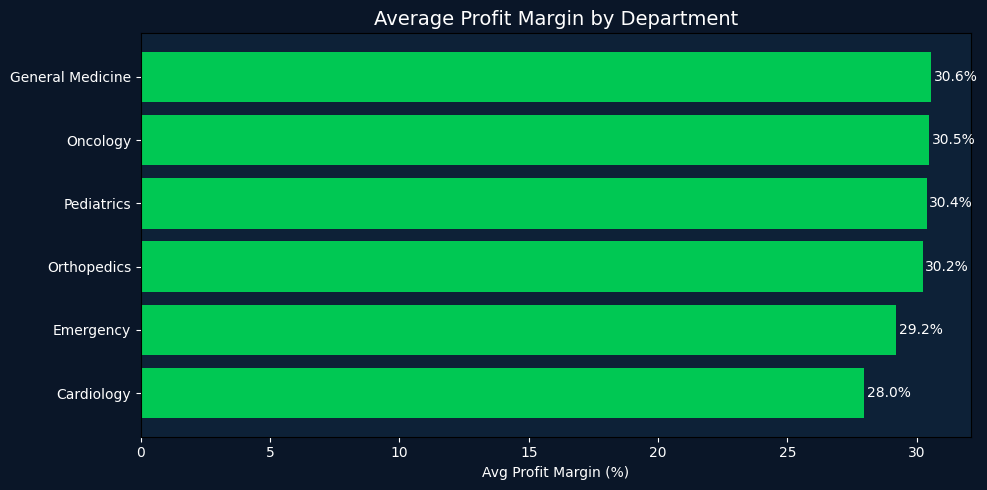


Highest margin dept: General Medicine (30.6%)
Lowest margin dept: Cardiology (28.0%)


In [4]:
dept_margin = df.groupby('Department')['Profit_Margin'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(dept_margin.index, dept_margin.values * 100, color=GREEN)
ax.set_xlabel('Avg Profit Margin (%)')
ax.set_title('Average Profit Margin by Department', color='white', fontsize=14)
for bar, val in zip(bars, dept_margin.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', color='white')
plt.tight_layout()
plt.show()

print('\nHighest margin dept:', dept_margin.idxmax(), f'({dept_margin.max()*100:.1f}%)')
print('Lowest margin dept:', dept_margin.idxmin(), f'({dept_margin.min()*100:.1f}%)')

## 5. Patient Distribution by Treatment Type

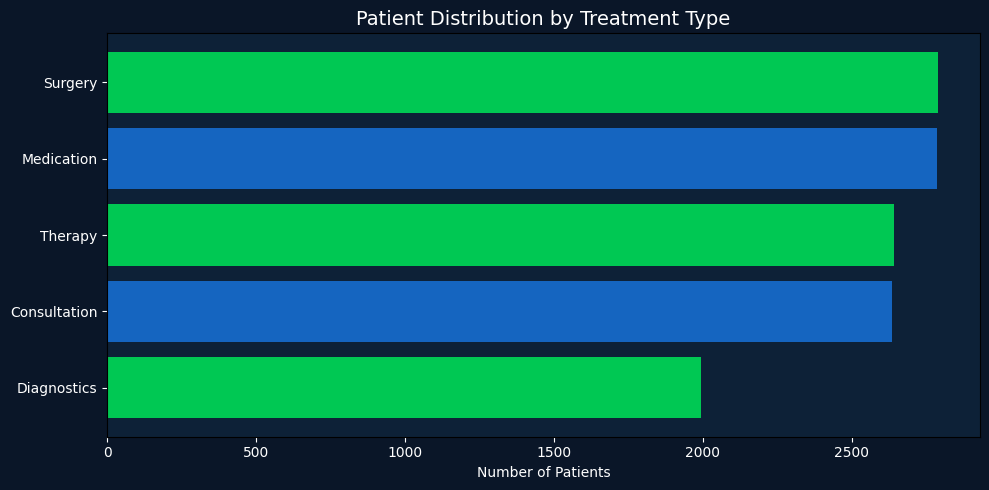

In [5]:
treatment = df.groupby('Treatment_Type')['Number_of_Patients'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [GREEN if i % 2 == 0 else BLUE for i in range(len(treatment))]
ax.barh(treatment.index, treatment.values, color=colors)
ax.set_xlabel('Number of Patients')
ax.set_title('Patient Distribution by Treatment Type', color='white', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Profit Margin Trend Over Time (by Region)

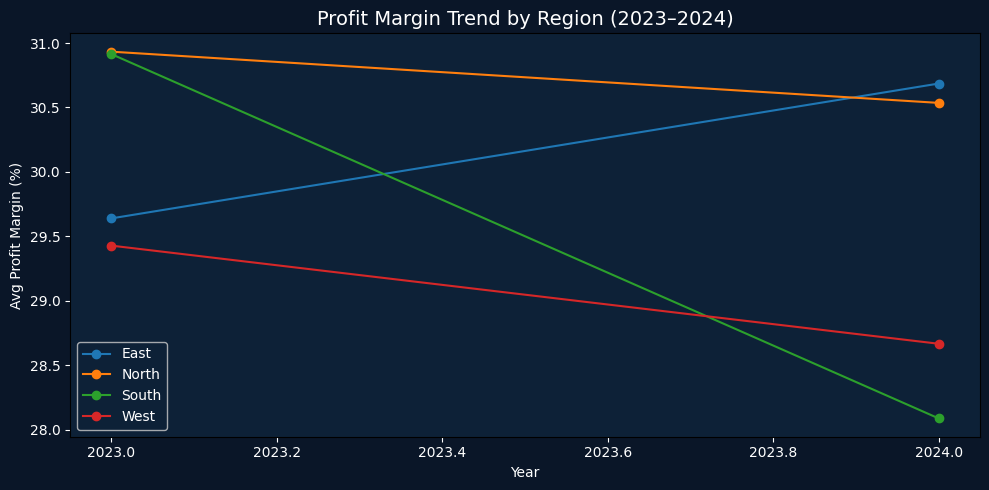

In [6]:
trend = df.groupby(['Year', 'Region'])['Profit_Margin'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for region in trend['Region'].unique():
    data = trend[trend['Region'] == region]
    ax.plot(data['Year'], data['Profit_Margin'] * 100, marker='o', label=region)
ax.set_xlabel('Year')
ax.set_ylabel('Avg Profit Margin (%)')
ax.set_title('Profit Margin Trend by Region (2023–2024)', color='white', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Payment Method Distribution

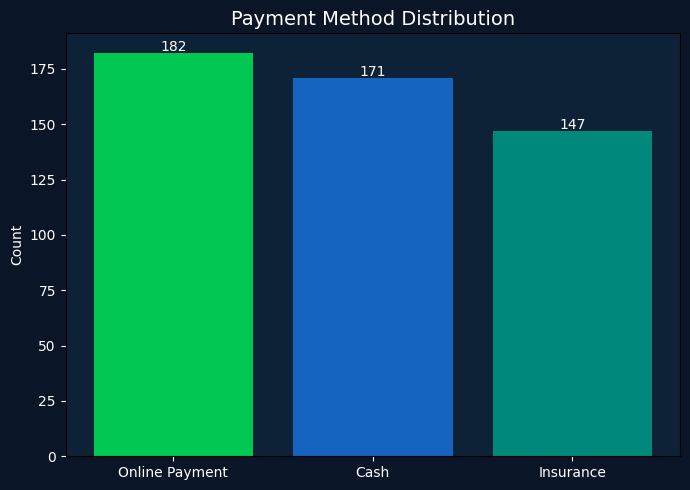

In [7]:
payment = df['Payment_Method'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(payment.index, payment.values, color=[GREEN, BLUE, '#00897B'])
ax.set_title('Payment Method Distribution', color='white', fontsize=14)
ax.set_ylabel('Count')
for i, v in enumerate(payment.values):
    ax.text(i, v + 1, str(v), ha='center', color='white')
plt.tight_layout()
plt.show()

## 8. Correlation Heatmap

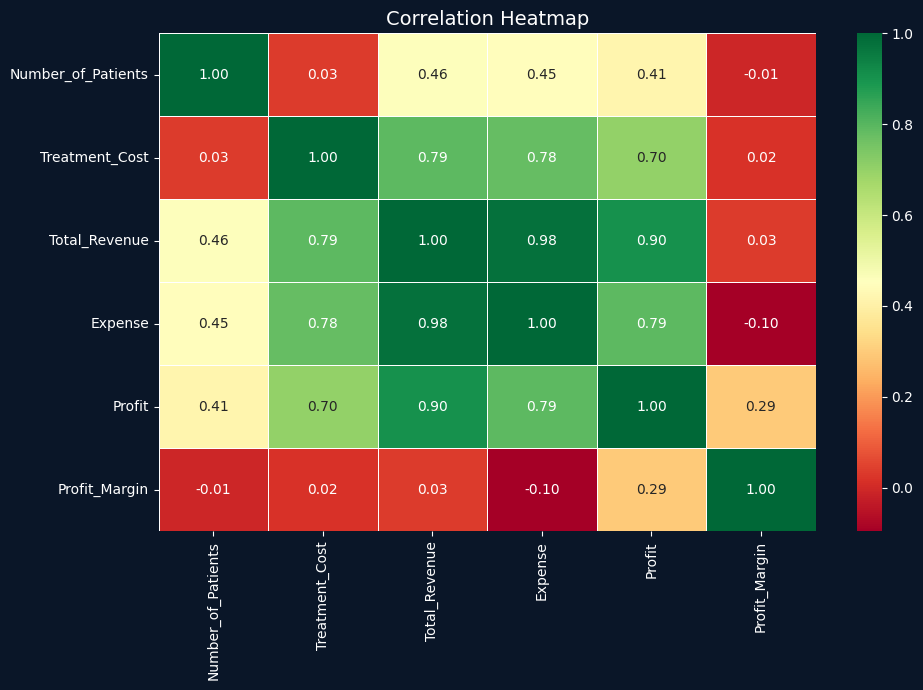

In [8]:
num_cols = ['Number_of_Patients', 'Treatment_Cost', 'Total_Revenue', 'Expense', 'Profit', 'Profit_Margin']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, annot_kws={'size': 10})
ax.set_title('Correlation Heatmap', color='white', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Key Insights

| # | Insight |
|---|---------|
| 1 | **South region** generates the highest total revenue (₹8.8M) |
| 2 | **General Medicine** has the highest profit margin (~30.5%) |
| 3 | **Cardiology** has the lowest profit margin (~27.9%) |
| 4 | **Surgery & Medication** serve the most patients |
| 5 | Revenue grew slightly from 2023 (₹16.4M) to 2024 (₹16.6M) |
| 6 | **Online Payment** is the most common payment method |
| 7 | Strong positive correlation between Number_of_Patients and Total_Revenue |